# Microsoft Stock Price Prediction using LSTM

This notebook demonstrates how to use Long Short-Term Memory (LSTM) neural networks to predict Microsoft stock prices. The analysis includes:

1. **Data Loading and Exploration**
2. **Data Visualization** 
3. **Data Preprocessing**
4. **LSTM Model Building**
5. **Training and Evaluation**
6. **Predictions and Results**

## 1. Import Required Libraries

First, let's import all the necessary libraries for data manipulation, visualization, and deep learning.

In [3]:
from tensorflow import keras 
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import seaborn as sns 
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Data Loading and Initial Exploration

Let's load the Microsoft stock data and examine its structure.

In [4]:
# Load the dataset
data = pd.read_csv("data/MicrosoftStock.csv")

print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())

Dataset shape: (1259, 8)

First 5 rows:
    index        date   open   high    low  close    volume  Name
0  390198  2013-02-08  27.35  27.71  27.31  27.55  33318306  MSFT
1  390199  2013-02-11  27.65  27.92  27.50  27.86  32247549  MSFT
2  390200  2013-02-12  27.88  28.00  27.75  27.88  35990829  MSFT
3  390201  2013-02-13  27.93  28.11  27.88  28.03  41715530  MSFT
4  390202  2013-02-14  27.92  28.06  27.87  28.04  32663174  MSFT


In [5]:
# Dataset information and statistics
print("Dataset Information:")
print(data.info())
print("\nDataset Statistics:")
print(data.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1259 non-null   int64  
 1   date    1259 non-null   object 
 2   open    1259 non-null   float64
 3   high    1259 non-null   float64
 4   low     1259 non-null   float64
 5   close   1259 non-null   float64
 6   volume  1259 non-null   int64  
 7   Name    1259 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 78.8+ KB
None

Dataset Statistics:
               index         open         high          low        close  \
count    1259.000000  1259.000000  1259.000000  1259.000000  1259.000000   
mean   390827.000000    51.026394    51.436007    50.630397    51.063081   
std       363.586303    14.859387    14.930144    14.774630    14.852117   
min    390198.000000    27.350000    27.600000    27.230000    27.370000   
25%    390512.500000    40.305000 

## 3. Data Visualization

Let's visualize the stock data to understand trends and patterns.

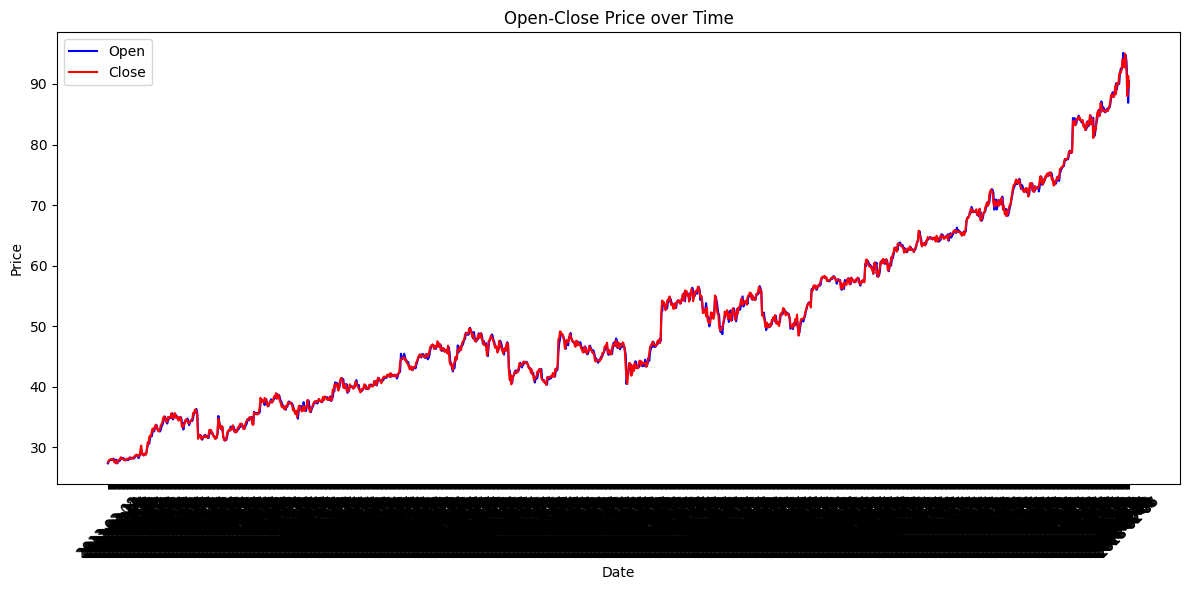

In [6]:
# Plot 1 - Open and Close Prices over time
plt.figure(figsize=(12,6))
plt.plot(data['date'], data['open'], label="Open", color="blue")
plt.plot(data['date'], data['close'], label="Close", color="red")
plt.title("Open-Close Price over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=90)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

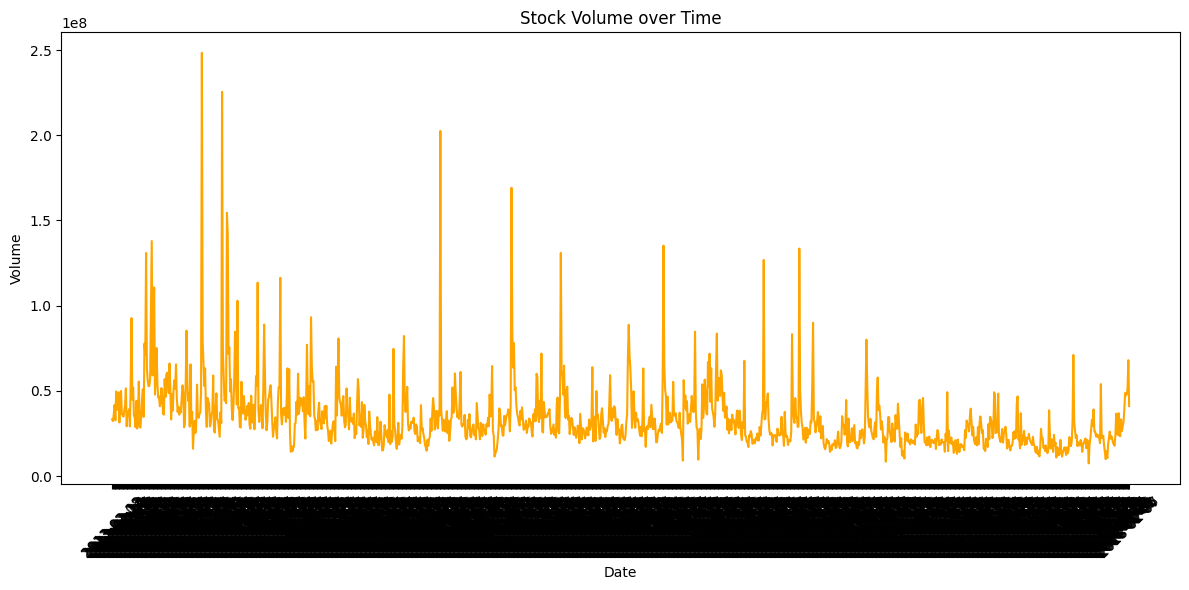

In [7]:
# Plot 2 - Trading Volume (check for outliers)
plt.figure(figsize=(12,6))
plt.plot(data['date'], data['volume'], label="Volume", color="orange")
plt.title("Stock Volume over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

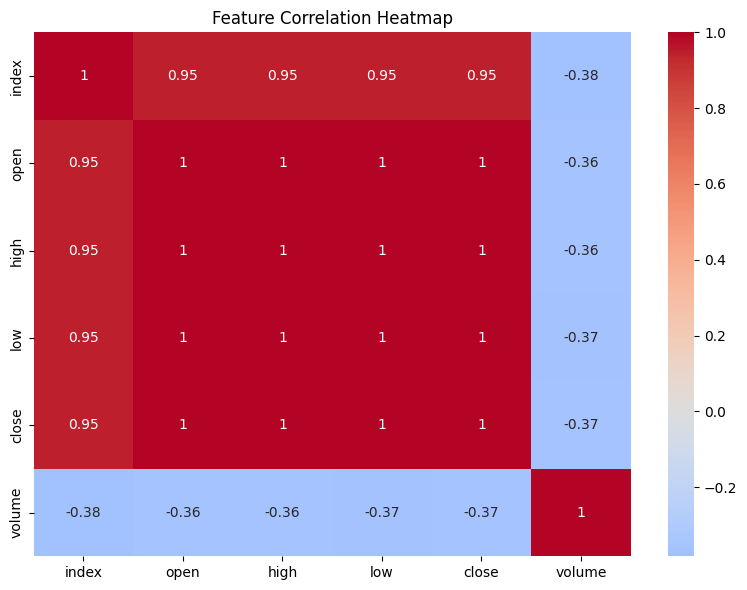

In [8]:
# Plot 3 - Feature Correlation Heatmap
# Drop non-numeric columns for correlation analysis
numeric_data = data.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

prepare our data for the LSTM model by converting dates and filtering the dataset.

In [9]:
# Convert the date column to datetime
data['date'] = pd.to_datetime(data['date'])

# Create a date filter for prediction period (2013-2018)
prediction = data.loc[
    (data['date'] > datetime(2013,1,1)) &
    (data['date'] < datetime(2018,1,1))
]

print(f"Original dataset: {len(data)} records")
print(f"Filtered dataset (2013-2018): {len(prediction)} records")

Original dataset: 1259 records
Filtered dataset (2013-2018): 1233 records


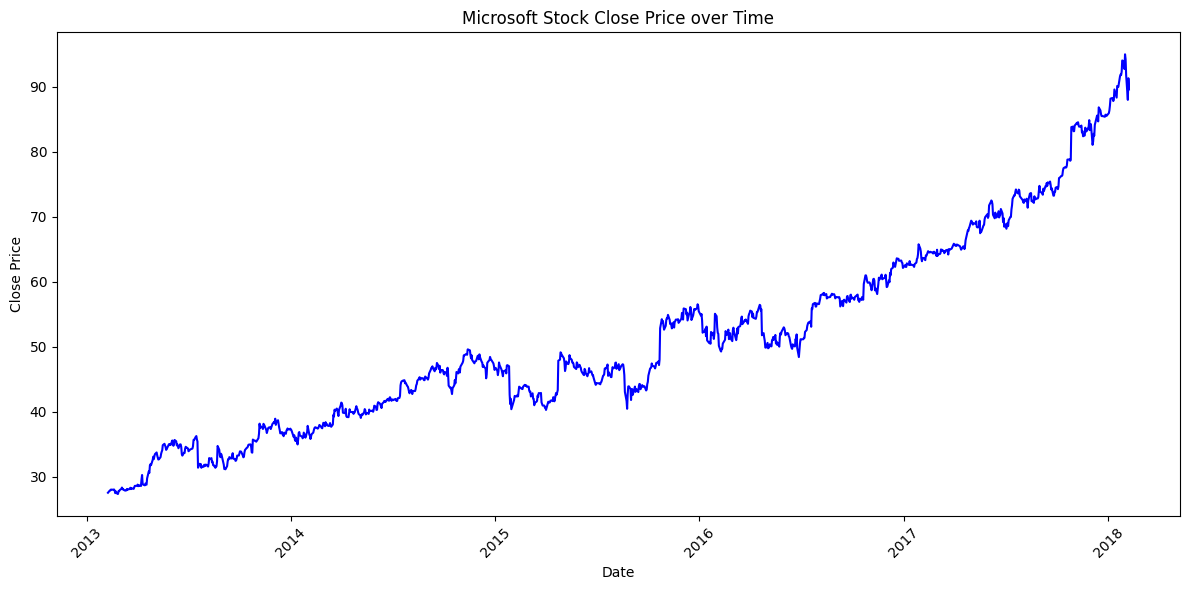

In [10]:
# Visualize the close price over time
plt.figure(figsize=(12,6))
plt.plot(data['date'], data['close'], color="blue")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Microsoft Stock Close Price over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Prepare Data for LSTM Model

prepare the data specifically for the LSTM model by creating sequences and scaling the data.

In [11]:
# Prepare data for LSTM Model (Sequential)
stock_close = data.filter(["close"])
dataset = stock_close.values  # Convert to numpy array
training_data_len = int(np.ceil(len(dataset) * 0.95))

print(f"Total dataset length: {len(dataset)}")
print(f"Training data length (95%): {training_data_len}")
print(f"Test data length (5%): {len(dataset) - training_data_len}")

Total dataset length: 1259
Training data length (95%): 1197
Test data length (5%): 62


In [12]:
# Scale the data using StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

# Create training data (95% of all data)
training_data = scaled_data[:training_data_len]

print("Data scaling completed!")
print(f"Original data range: {dataset.min():.2f} to {dataset.max():.2f}")
print(f"Scaled data range: {scaled_data.min():.2f} to {scaled_data.max():.2f}")

Data scaling completed!
Original data range: 27.37 to 95.01
Scaled data range: -1.60 to 2.96


In [13]:
# Create sequences for training (sliding window of 60 days)
X_train, y_train = [], []

# Create a sliding window for our stock (60 days)
for i in range(60, len(training_data)):
    X_train.append(training_data[i-60:i, 0])  # Past 60 days
    y_train.append(training_data[i, 0])        # Current day
    
# Convert to numpy arrays
X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape X_train for LSTM input [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

print(f"Training sequences created!")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Training sequences created!
X_train shape: (1137, 60, 1)
y_train shape: (1137,)


## 6. Build the LSTM Model

 LSTM neural network architecture.

In [14]:
# Build the LSTM Model
model = keras.models.Sequential()

# First LSTM Layer (returns sequences for the next LSTM layer)
model.add(keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))

# Second LSTM Layer (doesn't return sequences)
model.add(keras.layers.LSTM(64, return_sequences=False))

# Dense Layer with ReLU activation
model.add(keras.layers.Dense(128, activation="relu"))

# Dropout Layer for regularization
model.add(keras.layers.Dropout(0.5))

# Final Output Layer
model.add(keras.layers.Dense(1))

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="mae",  # Mean Absolute Error
    metrics=[keras.metrics.RootMeanSquaredError()]
)

print("Model compiled successfully!")

Model compiled successfully!


## 7. Train the Model

train our LSTM model on the prepared training data.

In [16]:
# Train the model
print("Starting model training...")
training_history = model.fit(
    X_train, 
    y_train, 
    epochs=20, 
    batch_size=32,
    verbose=1
)

print("Model training completed!")

Starting model training...
Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.2627 - root_mean_squared_error: 0.3798
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.1355 - root_mean_squared_error: 0.1823
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.1168 - root_mean_squared_error: 0.1590
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1198 - root_mean_squared_error: 0.1627
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1117 - root_mean_squared_error: 0.1567
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1160 - root_mean_squared_error: 0.1582
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.1033 - root_mean_squared_error: 0.1393
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.1050 - root_mean_squared_error: 0.1417
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.1065 - root_mean_squared_error: 0.1456
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.1048 - root

## 8. Prepare Test Data and Make Predictions

prepare the test data and use our trained model to make predictions.

In [17]:
# Prepare the test data
test_data = scaled_data[training_data_len - 60:]  # Include 60 days before test period
X_test = []
y_test = dataset[training_data_len:]  # Actual values for comparison

# Create test sequences
for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    
# Convert to numpy array and reshape
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Test data prepared!")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Test data prepared!
X_test shape: (62, 60, 1)
y_test shape: (62, 1)


In [18]:
# Make predictions
print("Making predictions...")
predictions = model.predict(X_test)

# Inverse transform predictions to original scale
predictions = scaler.inverse_transform(predictions)

print("Predictions completed and scaled back to original values!")

Making predictions...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step
Predictions completed and scaled back to original values!


## 9. Visualize Results

visualize our predictions compared to the actual stock prices.

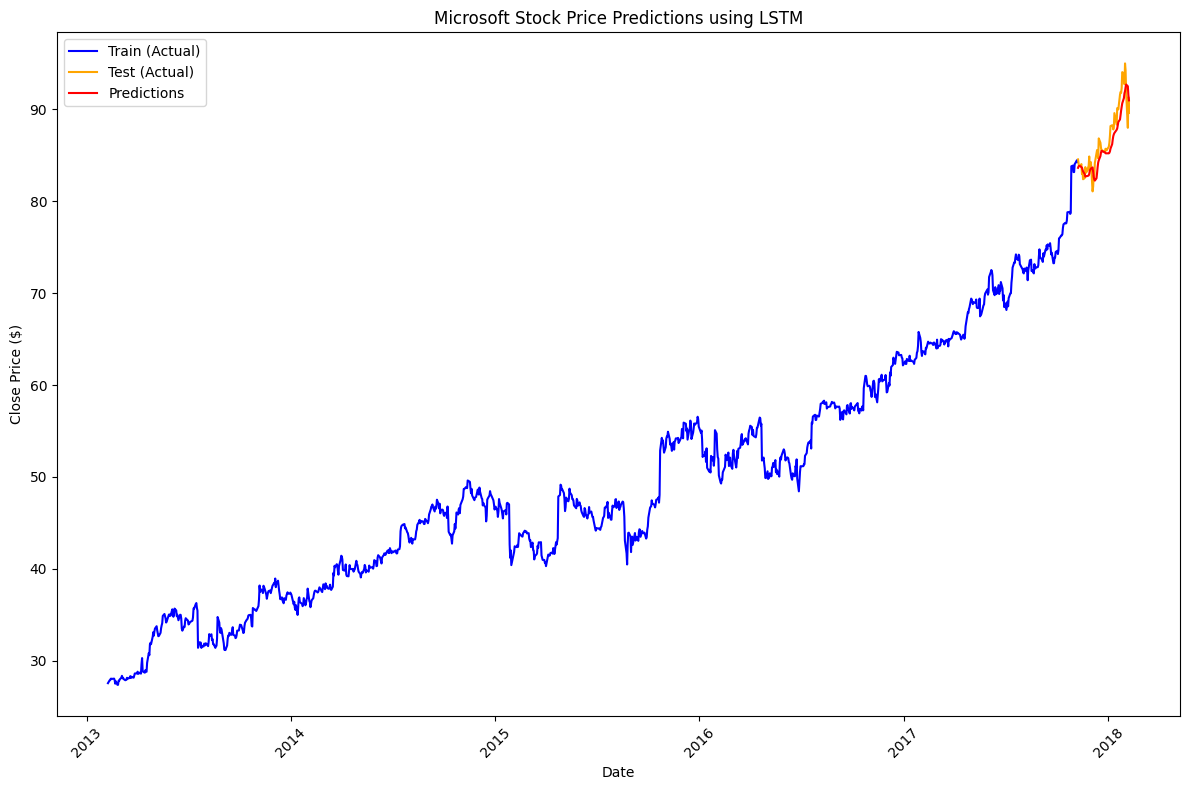

Visualization completed!


In [19]:
# Prepare data for plotting
train = data[:training_data_len]
test = data[training_data_len:].copy()

# Add predictions to test data
test['Predictions'] = predictions

# Plot the results
plt.figure(figsize=(12,8))
plt.plot(train['date'], train['close'], label="Train (Actual)", color='blue')
plt.plot(test['date'], test['close'], label="Test (Actual)", color='orange')
plt.plot(test['date'], test['Predictions'], label="Predictions", color='red')
plt.title("Microsoft Stock Price Predictions using LSTM")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Visualization completed!")

## 10. Model Evaluation

In [20]:
# Calculate evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

# Get actual vs predicted values
actual = test['close'].values
predicted = test['Predictions'].values.flatten()

# Calculate metrics
mse = mean_squared_error(actual, predicted)
rmse = math.sqrt(mse)
mae = mean_absolute_error(actual, predicted)

# Calculate MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print("Model Performance Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Display some sample predictions
print(f"\nSample Predictions:")
print(f"Actual: {actual[:5]}")
print(f"Predicted: {predicted[:5]}")

Model Performance Metrics:
Mean Squared Error (MSE): 2.56
Root Mean Squared Error (RMSE): 1.60
Mean Absolute Error (MAE): 1.24
Mean Absolute Percentage Error (MAPE): 1.41%

Sample Predictions:
Actual: [84.56 84.09 83.87 83.93 84.05]
Predicted: [83.64182 83.81506 83.8536  83.79145 83.71319]
